# Titanic — Exploratory Data Analysis

**Goal of this notebook.** Understand the Titanic training data well enough to make
*deliberate* preprocessing and modelling choices in the bricks that follow
(`preprocessing`, `model.py`, `train.py`). Rather than dumping plots, every section
ends with a short **Insight** that states what we learned and how it should change
what we build next.

We work **only** with `data/train.csv` (per the assignment); the validation split is
carved out of it later. No leakage from `test.csv`.

**Roadmap**
1. Load & first look
2. Missingness
3. Target balance
4. Numeric distributions
5. Survival by categorical feature (Sex, Pclass, Embarked)
6. Survival vs continuous features (Age, Fare)
7. Engineered features (Title, FamilySize, IsAlone)
8. Non-linear interactions (Sex × Pclass, Age × Pclass)
9. Correlations
10. Summary — implications for preprocessing & modelling

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


def find_data() -> Path:
    """Locate the training CSV regardless of the working directory.

    Searches for ``train.csv`` (and falls back to the committed ``sample.csv``)
    relative to both the notebook folder and the repo root, so the notebook runs
    whether launched from ``notebooks/`` or the project root, and even without
    Kaggle credentials.

    Returns:
        Path to the best available CSV.

    Raises:
        FileNotFoundError: If neither ``train.csv`` nor ``sample.csv`` is found.
    """
    candidates = [
        Path("data/train.csv"),
        Path("../data/train.csv"),
        Path("data/sample.csv"),
        Path("../data/sample.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "No data file found. Run `python fetch_data.py` first, or ensure "
        "data/sample.csv is present."
    )


DATA_PATH = find_data()
df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}  —  {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded ..\data\train.csv  —  891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. First look

The 12 columns split naturally into:
- **Target:** `Survived` (0/1)
- **Identifiers / free text:** `PassengerId`, `Name`, `Ticket`, `Cabin` (mostly not usable raw, but `Name` hides a *Title* and `Cabin` hides a *Deck*)
- **Categorical:** `Pclass`, `Sex`, `Embarked`
- **Numeric:** `Age`, `SibSp`, `Parch`, `Fare`

In [2]:
df.info()
print("\nNumeric summary:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

Numeric summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
print("Cardinality of object/categorical columns:")
for col in ["Sex", "Embarked", "Pclass", "Ticket", "Cabin", "Name"]:
    print(f"  {col:9s}: {df[col].nunique()} unique")

Cardinality of object/categorical columns:
  Sex      : 2 unique
  Embarked : 3 unique
  Pclass   : 3 unique
  Ticket   : 681 unique
  Cabin    : 147 unique
  Name     : 891 unique


## 2. Missingness

Before anything else: where are the holes? This dictates the imputation strategy in
the preprocessing brick.

,missing,pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


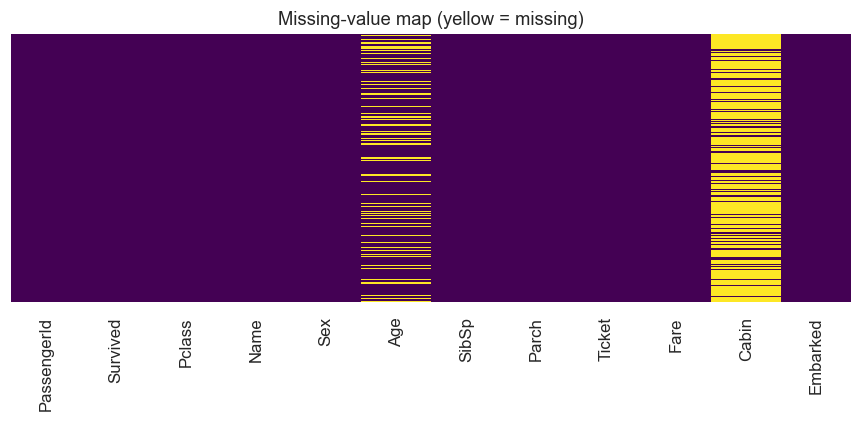

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({"missing": missing, "pct": missing_pct})
display(missing_table)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing-value map (yellow = missing)")
plt.tight_layout()
plt.show()

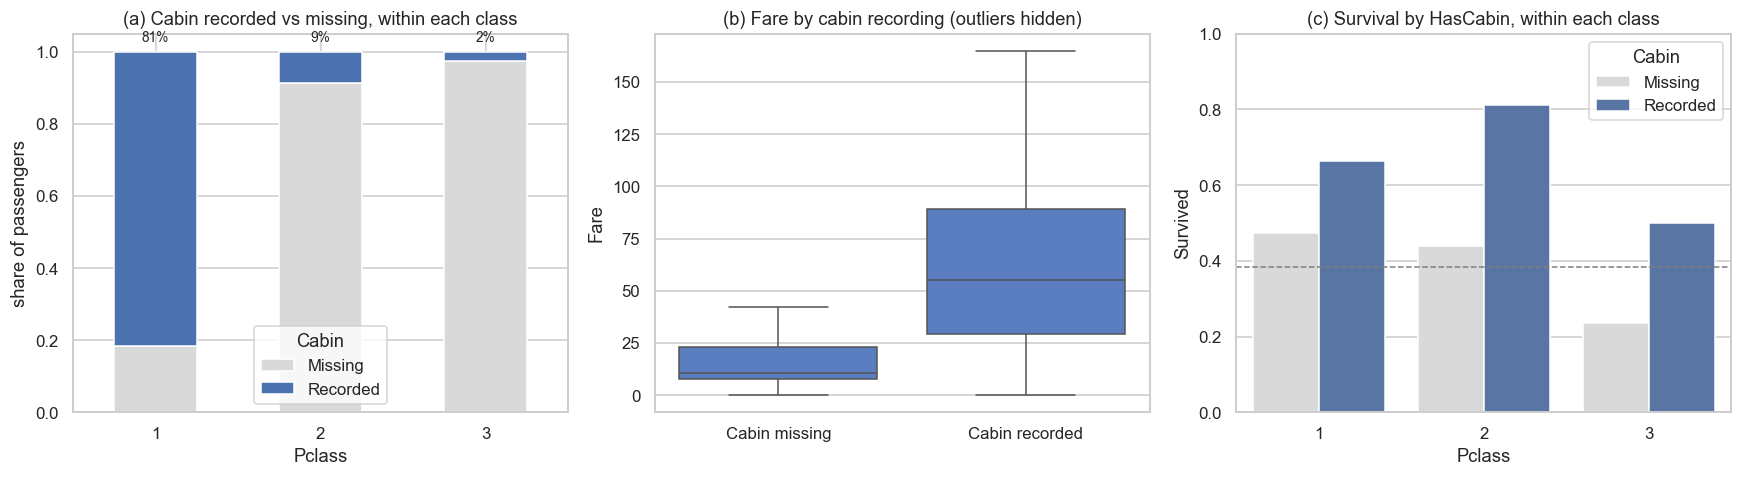

Share with a recorded cabin, by class:
Pclass
1    0.815
2    0.087
3    0.024

Point-biserial-style correlations of HasCabin:
HasCabin    1.000
Pclass     -0.726
Fare        0.482
Survived    0.317


In [5]:
# A closer look: is a *missing* Cabin really tied to class, or just noise?
# We make the missingness explicit (HasCabin) and probe it from three angles
# instead of plotting a single "% missing per class" bar.
cab = df.copy()
cab["HasCabin"] = cab["Cabin"].notna().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Within each class, what share had a cabin recorded? (100%-stacked)
share = (
    pd.crosstab(cab["Pclass"], cab["HasCabin"], normalize="index")
    .rename(columns={0: "Missing", 1: "Recorded"})
)
share.plot(kind="bar", stacked=True, ax=axes[0],
           color=["#d9d9d9", "#4c72b0"])
axes[0].set_title("(a) Cabin recorded vs missing, within each class")
axes[0].set_ylabel("share of passengers")
axes[0].set_xlabel("Pclass")
axes[0].legend(title="Cabin", loc="lower center")
axes[0].tick_params(axis="x", rotation=0)
for cls in share.index:  # annotate the recorded share
    axes[0].text(cls - 1, 1.02, f"{share.loc[cls, 'Recorded']:.0%}",
                 ha="center", va="bottom", fontsize=9)

# (b) The *mechanism*: recorded cabins map to far higher fares.
sns.boxplot(data=cab, x="HasCabin", y="Fare", showfliers=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Cabin missing", "Cabin recorded"])
axes[1].set_title("(b) Fare by cabin recording (outliers hidden)")
axes[1].set_xlabel("")

# (c) Does HasCabin carry signal *beyond* class? Survival by HasCabin within class.
sns.barplot(data=cab, x="Pclass", y="Survived", hue="HasCabin",
            errorbar=None, ax=axes[2], palette=["#d9d9d9", "#4c72b0"])
axes[2].set_title("(c) Survival by HasCabin, within each class")
axes[2].set_ylim(0, 1)
axes[2].axhline(df["Survived"].mean(), ls="--", color="grey", lw=1)
handles, _ = axes[2].get_legend_handles_labels()
axes[2].legend(handles, ["Missing", "Recorded"], title="Cabin")

plt.tight_layout()
plt.show()

print("Share with a recorded cabin, by class:")
print((share["Recorded"]).round(3).to_string())
print()
print("Point-biserial-style correlations of HasCabin:")
print(cab[["HasCabin", "Pclass", "Fare", "Survived"]].corr()["HasCabin"].round(3).to_string())

> **Insight — missingness.**
> - **`Cabin` is ~77% missing** — too sparse to use as-is. But *whether* a cabin was
>   recorded may itself be informative (recorded cabins skew first-class). We'll test a
>   binary `HasCabin` feature instead of dropping the signal entirely.
> - **`Age` is ~20% missing** — worth imputing, not dropping (we'd lose 1/5 of the data).
>   A smart impute is *median Age within (Sex, Pclass, Title)* groups rather than a global median.
> - **`Embarked` has only 2 missing** — fill with the mode (`S`).
> - The missingness is **not** uniformly random (Cabin correlates with class), so the
>   imputation choice carries real signal.

## 3. Target balance

Is the classification problem balanced? This sets the baseline accuracy a model must beat
and tells us whether to care about precision/recall over raw accuracy.

Survival rate: 38.4%
Majority-class (always-predict-0) accuracy baseline: 61.6%


C:\Users\Omer Bassan\AppData\Local\Temp\ipykernel_31048\2400072463.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Died (0)", "Survived (1)"])


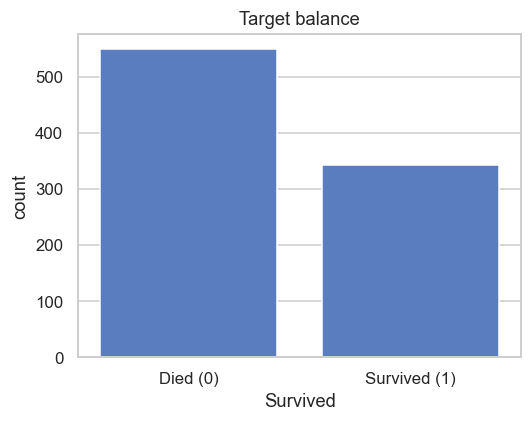

In [6]:
rate = df["Survived"].mean()
print(f"Survival rate: {rate:.1%}")
print(f"Majority-class (always-predict-0) accuracy baseline: {1 - rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Survived", ax=ax)
ax.set_xticklabels(["Died (0)", "Survived (1)"])
ax.set_title("Target balance")
plt.tight_layout()
plt.show()

> **Insight — target.** ~38% survived, so the data is **mildly imbalanced**. A trivial
> "everyone dies" model already scores ~62% accuracy — our model must clear that bar, and we
> should report **F1 and ROC-AUC**, not accuracy alone, so the minority (survivors) isn't ignored.

## 4. Numeric distributions

Shape of the continuous features — reveals skew (→ needs scaling/log) and outliers.

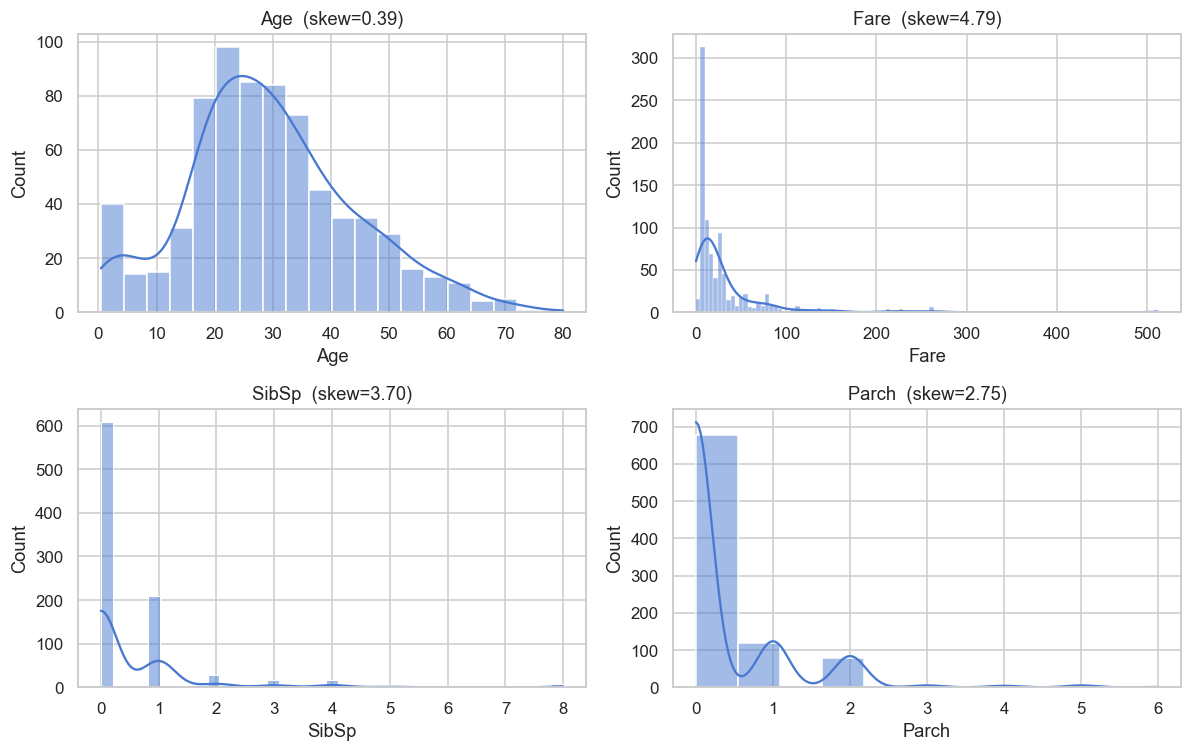

In [7]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

> **Insight — distributions.**
> - **`Fare` is heavily right-skewed** (a few luxury fares). A `log1p(Fare)` transform plus
>   standardisation will help any gradient-based model.
> - **`Age`** is roughly normal with a bump at young children — useful, since children were
>   prioritised ("women and children first").
> - **`SibSp` / `Parch`** are zero-inflated counts — most travel alone. They're better combined
>   into a single `FamilySize` feature (explored in §7) than used raw.

## 5. Survival by categorical feature

The headline drivers. Bars show survival *rate* (not count) so classes of different sizes
are comparable.

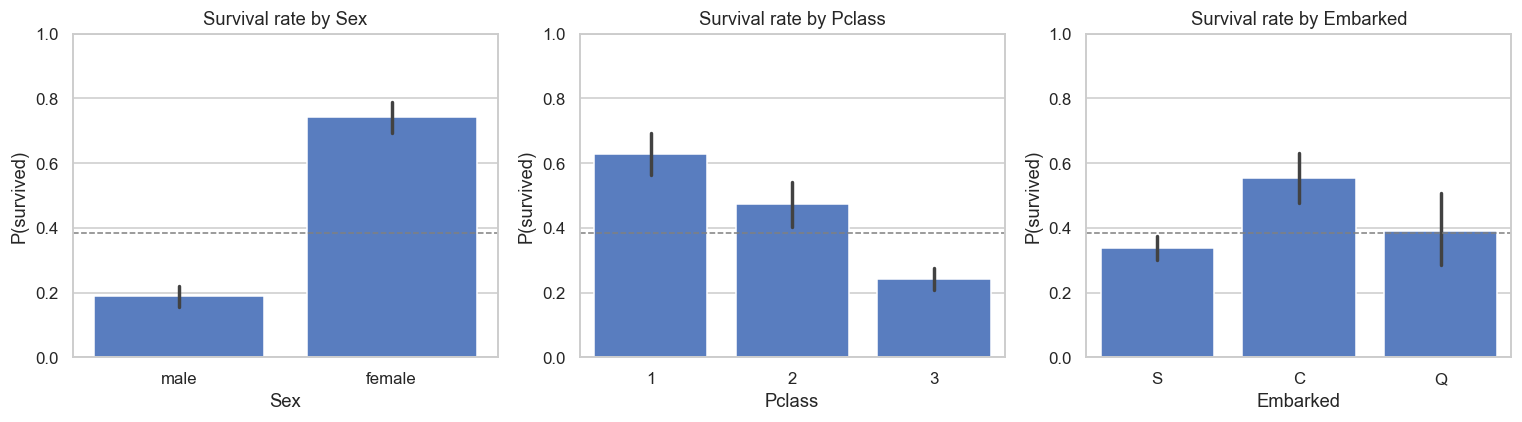


Survival rate by Sex:
         mean  count
Sex                 
female  0.742    314
male    0.189    577

Survival rate by Pclass:
         mean  count
Pclass              
1       0.630    216
2       0.473    184
3       0.242    491

Survival rate by Embarked:
           mean  count
Embarked              
C         0.554    168
Q         0.390     77
S         0.337    644


In [8]:
cat_cols = ["Sex", "Pclass", "Embarked"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    sns.barplot(data=df, x=col, y="Survived", ax=ax, errorbar=("ci", 95))
    ax.set_ylim(0, 1)
    ax.axhline(rate, ls="--", color="grey", lw=1)
    ax.set_title(f"Survival rate by {col}")
    ax.set_ylabel("P(survived)")
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\nSurvival rate by {col}:")
    print(df.groupby(col)["Survived"].agg(["mean", "count"]).round(3))

> **Insight — categoricals.**
> - **`Sex` is the single strongest predictor:** ~74% of women survived vs ~19% of men.
>   Any model that ignores `Sex` is hopeless.
> - **`Pclass` is a strong monotonic signal:** 1st ≈ 63%, 2nd ≈ 47%, 3rd ≈ 24%. A proxy for
>   wealth and cabin location (closer to lifeboats).
> - **`Embarked`** matters mildly (C > Q > S), but this is largely *confounded* by class —
>   Cherbourg boarded more first-class passengers. Keep it, but don't over-read it.

## 6. Survival vs continuous features

Do `Age` and `Fare` separate survivors from non-survivors?

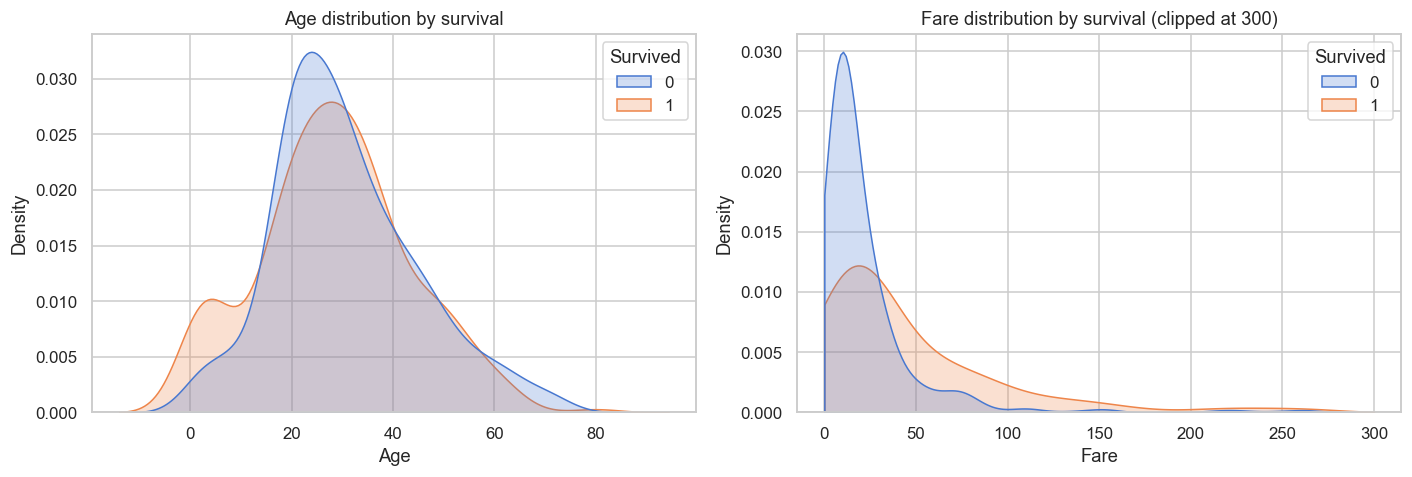

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.kdeplot(data=df, x="Age", hue="Survived", common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Age distribution by survival")
sns.kdeplot(
    data=df, x="Fare", hue="Survived", common_norm=False, fill=True, clip=(0, 300), ax=axes[1]
)
axes[1].set_title("Fare distribution by survival (clipped at 300)")
plt.tight_layout()
plt.show()

> **Insight — continuous.**
> - **Young children (`Age` < ~10) survived at a clearly higher rate** — the only age band where
>   the survivor curve sits above the non-survivor curve. This is a *non-linear* effect, so a
>   model that can bend (or an explicit `IsChild` feature) beats a purely linear `Age` term.
> - **Higher `Fare` → higher survival**, but this overlaps heavily with `Pclass`. The fare signal
>   is mostly the class signal in disguise.

## 7. Engineered features

The raw columns hide stronger signals. We prototype three engineered features here so the
preprocessing brick can implement them with evidence behind each.
- **`Title`** extracted from `Name` (Mr/Mrs/Miss/Master/Rare) — encodes sex, marital status, and age.
- **`FamilySize`** = `SibSp` + `Parch` + 1.
- **`IsAlone`** = travelling with no family.

C:\Users\Omer Bassan\AppData\Local\Temp\ipykernel_31048\2020268193.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(["With family", "Alone"])


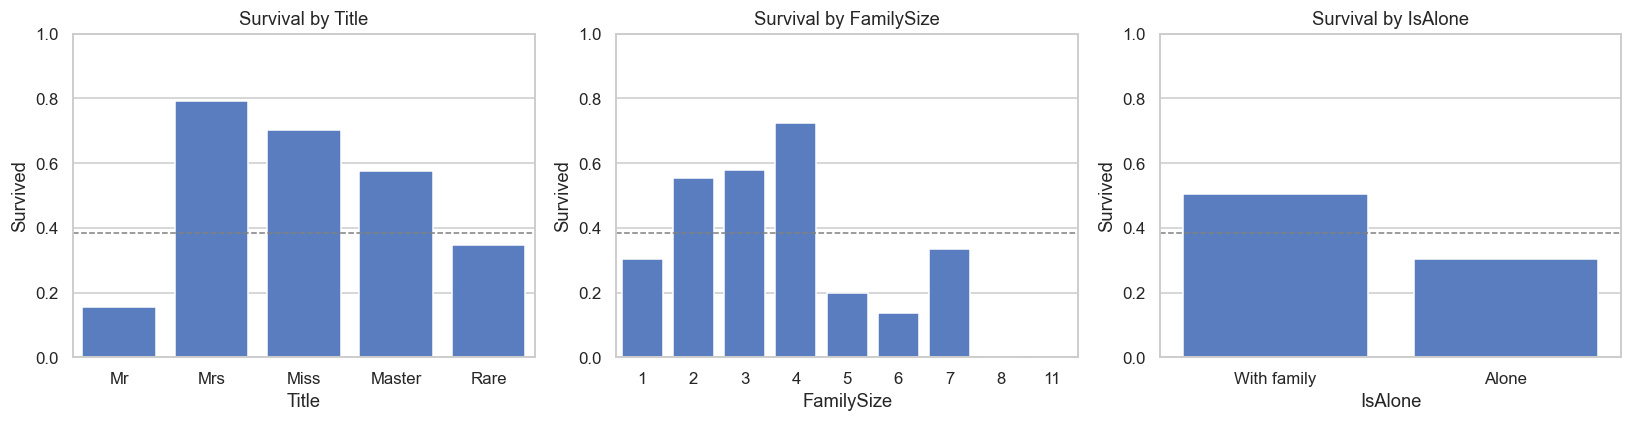

         mean  count
Title               
Master  0.575     40
Miss    0.703    185
Mr      0.157    517
Mrs     0.794    126
Rare    0.348     23


In [10]:
eda = df.copy()

# Title from Name: the substring between ', ' and '.'
eda["Title"] = eda["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
rare = eda["Title"].value_counts()[lambda s: s < 10].index
title_map = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
eda["Title"] = eda["Title"].replace(title_map)
eda["Title"] = eda["Title"].where(~eda["Title"].isin(rare), "Rare")

eda["FamilySize"] = eda["SibSp"] + eda["Parch"] + 1
eda["IsAlone"] = (eda["FamilySize"] == 1).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=eda, x="Title", y="Survived", ax=axes[0], errorbar=None,
            order=["Mr", "Mrs", "Miss", "Master", "Rare"])
axes[0].set_title("Survival by Title")
sns.barplot(data=eda, x="FamilySize", y="Survived", ax=axes[1], errorbar=None)
axes[1].set_title("Survival by FamilySize")
sns.barplot(data=eda, x="IsAlone", y="Survived", ax=axes[2], errorbar=None)
axes[2].set_xticklabels(["With family", "Alone"])
axes[2].set_title("Survival by IsAlone")
for ax in axes:
    ax.set_ylim(0, 1)
    ax.axhline(rate, ls="--", color="grey", lw=1)
plt.tight_layout()
plt.show()

print(eda.groupby("Title")["Survived"].agg(["mean", "count"]).round(3))

> **Insight — engineered features.**
> - **`Title` is a powerhouse:** `Master` (boys) survive far above the male average, confirming
>   the child effect; `Mrs`/`Miss` track the female advantage. `Title` also gives us *better Age
>   imputation groups* than Sex alone (a `Master` is a child by definition).
> - **`FamilySize` is non-monotonic (U-shaped):** solo travellers and large families (5+) fared
>   worst; small families (2–4) did best. A linear term can't capture this — argues for binning
>   or a non-linear model.
> - **`IsAlone`** cleanly separates risk and is a cheap, robust feature.
> These three justify the feature-engineering step in the preprocessing brick.

## 8. Non-linear interactions

The assignment explicitly rewards finding *interactions*. The cleanest example: how survival
depends on **Sex and Pclass jointly**, and on **Age band within each class**.

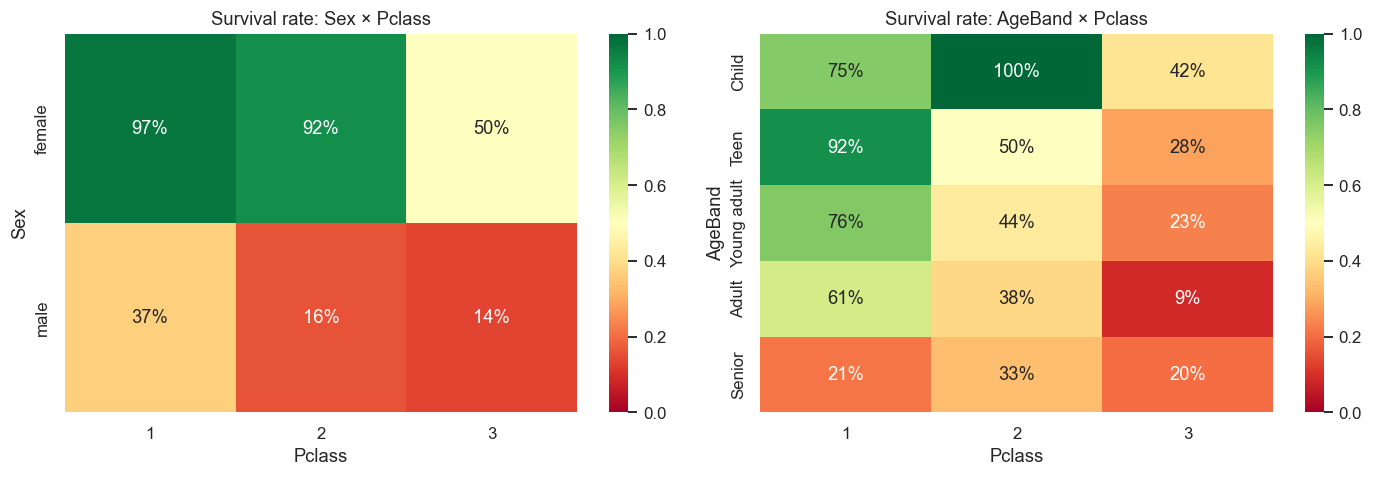

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [11]:
pivot_sex_class = eda.pivot_table(
    values="Survived", index="Sex", columns="Pclass", aggfunc="mean"
)

eda["AgeBand"] = pd.cut(
    eda["Age"], bins=[0, 12, 18, 35, 60, 120],
    labels=["Child", "Teen", "Young adult", "Adult", "Senior"],
)
pivot_age_class = eda.pivot_table(
    values="Survived", index="AgeBand", columns="Pclass", aggfunc="mean", observed=True
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pivot_sex_class, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Survival rate: Sex × Pclass")
sns.heatmap(pivot_age_class, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Survival rate: AgeBand × Pclass")
plt.tight_layout()
plt.show()

display(pivot_sex_class.round(3))

> **Insight — interactions (the creative core of the EDA).**
> - **The effect of `Pclass` is wildly different per sex.** First-class women survived at ~97%
>   while third-class women dropped to ~50% — a 47-point swing. For men the class effect exists
>   but the *level* is far lower (1st ≈ 37%, 3rd ≈ 14%). So class and sex don't add
>   independently; they **multiply**. A plain linear model treats them as additive and will
>   mis-state both. This is the clearest argument in the whole EDA for a **non-linear /
>   interaction-aware architecture** (the planned tabular ResNet / attention net) rather than
>   a vanilla logistic baseline.
> - **Age × Class:** being a child rescued you mostly in 1st/2nd class; 3rd-class children still
>   died at high rates (lifeboat access, not just age). Another genuine interaction.
> - **Takeaway for modelling:** either feed explicit interaction features (e.g. `Sex×Pclass`) to
>   a linear model, or let a deeper net learn them. The plan's tabular net is well motivated.

## 9. Correlations

A numeric correlation matrix (with `Sex` encoded) to confirm the linear signal strengths and
spot redundancy.

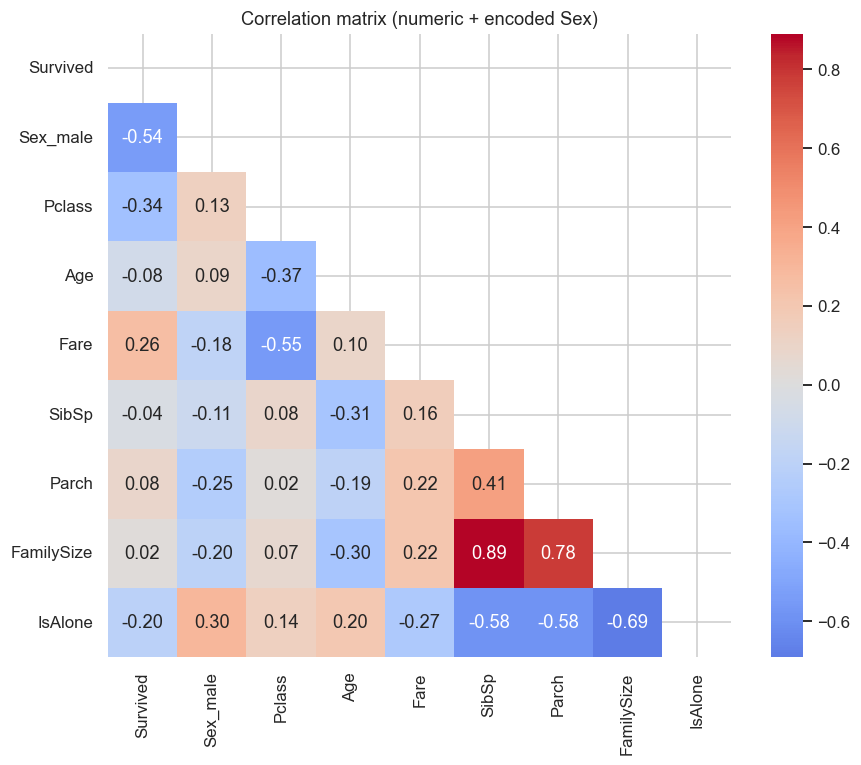

Correlation with Survived (sorted):
Sex_male     -0.543
Pclass       -0.338
Fare          0.257
IsAlone      -0.203
Parch         0.082
Age          -0.077
SibSp        -0.035
FamilySize    0.017
Name: Survived, dtype: float64


In [12]:
corr_df = eda.copy()
corr_df["Sex_male"] = (corr_df["Sex"] == "male").astype(int)
corr_cols = ["Survived", "Sex_male", "Pclass", "Age", "Fare", "SibSp", "Parch",
             "FamilySize", "IsAlone"]
corr = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax)
ax.set_title("Correlation matrix (numeric + encoded Sex)")
plt.tight_layout()
plt.show()

print("Correlation with Survived (sorted):")
print(corr["Survived"].drop("Survived").sort_values(key=abs, ascending=False).round(3))

> **Insight — correlations.**
> - Linear correlation with `Survived` ranks **`Sex_male` (−) > `Pclass` (−) > `Fare` (+)**, matching
>   the visual story. (Note Pclass=1 is *best*, so its negative sign is expected.)
> - **`SibSp`, `Parch`, `FamilySize`, `IsAlone` are mutually highly correlated** — they encode the
>   same thing. Feed the model *one* family representation, not all four, to avoid redundancy.
> - Crucially, `Age`'s linear correlation is weak — **but §6/§8 showed it matters non-linearly.**
>   This is the textbook reminder that a correlation matrix only sees *linear* structure; the
>   real Titanic signal lives in interactions a plain heatmap can't show.

## 10. Summary — decisions carried into the next bricks

**Preprocessing (Brick 3)**
- Impute `Age` by **median within (Title, Pclass)** groups, not a global median.
- Fill `Embarked` with mode `S`; fill the single missing `Fare` (if any in test-time) by class median.
- Replace sparse `Cabin` with a binary **`HasCabin`** flag.
- **`log1p(Fare)`** then standardise; standardise `Age`.
- Engineer **`Title`, `FamilySize`, `IsAlone`** (drop raw `Name`, `Ticket`, `PassengerId`).
- One-hot encode `Sex`, `Embarked`, `Title`, `Pclass`.
- Keep only one family-size representation to avoid redundancy.

**Modelling (Bricks 4–5)**
- The dominant signal is the **Sex × Pclass interaction** plus the **non-linear child effect** —
  this is the concrete justification for a non-linear tabular architecture (ResNet-style /
  attention) over a plain MLP or logistic baseline.
- Mild class imbalance (~38% positive) → evaluate with **F1 and ROC-AUC**, beat the ~62% baseline.

**Reproducibility**
- All randomness keyed off `RANDOM_STATE = 42`; the notebook runs top-to-bottom against
  `data/train.csv` (or the committed `data/sample.csv`).